d:\minicinda\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


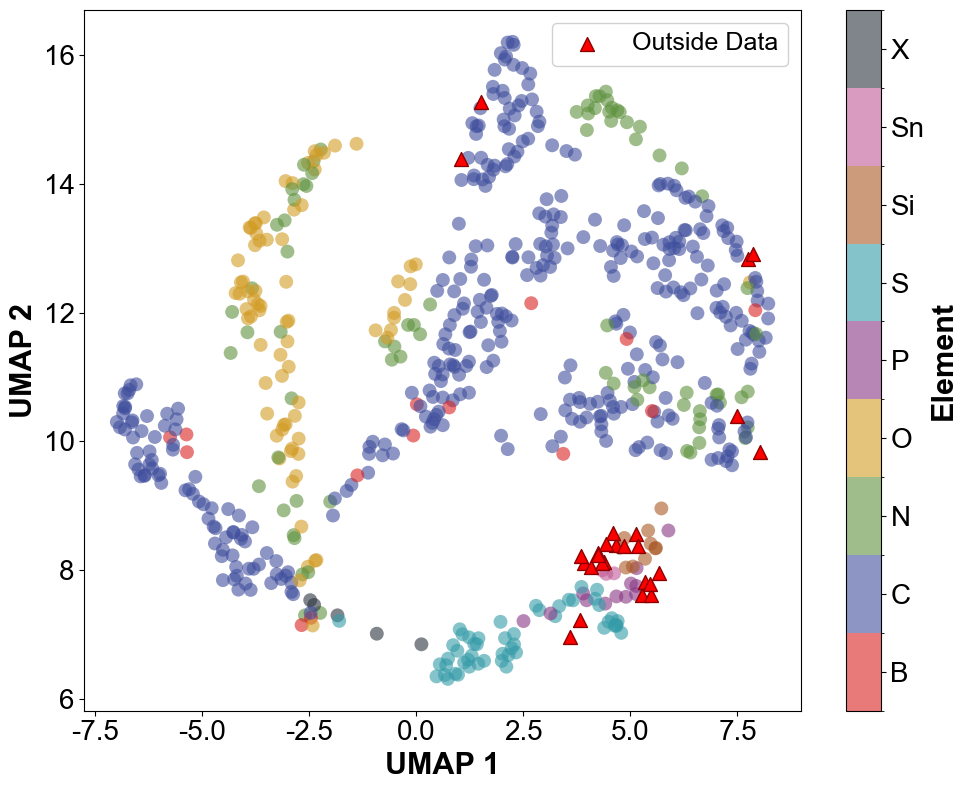

In [ ]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ==========================================
# 0. Font and Global Style Setup (Publication Standard Fonts)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False 

# ==========================================
# 1. Data Preparation Phase
# ==========================================
# Read main dataset
main_data_path = r"C:\Users\Lenovo\Desktop\ML-Electrophilicity\TrainingData\xyz_rdkitdescriptors.csv"
data = pd.read_csv(main_data_path)

# Read external validation dataset
test_data_path = r"C:\Users\Lenovo\Desktop\ML-Electrophilicity\TrainingData\OutofSamples.xlsx" 
test_data = pd.read_excel(test_data_path, sheet_name="Metal")

# Define feature columns for dimensionality reduction
feature_columns = ['lumo', 'Charge', 'AN', 'EN', 'Density', 'DP', 'homo', 'disp', 'ANN', 'ENN', 'BV']

# Extract feature data
X_train = data[feature_columns]
y_train_an = data['AN'] 
X_test = test_data[feature_columns]

# ==========================================
# 2. UMAP Dimensionality Reduction
# ==========================================
reducer = umap.UMAP(n_neighbors=55, min_dist=0.5, random_state=42)
embedding_train = reducer.fit_transform(X_train)
embedding_test = reducer.transform(X_test)

# ==========================================
# 3. Group Mapping and Color Palette Configuration
# ==========================================
an_to_symbol = {
    1: 'H', 2: 'He', 3: 'Li', 4: 'Be', 5: 'B', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 10: 'Ne',
    11: 'Na', 12: 'Mg', 13: 'Al', 14: 'Si', 15: 'P', 16: 'S', 17: 'Cl', 18: 'Ar',
    19: 'K', 20: 'Ca', 21: 'Sc', 22: 'Ti', 23: 'V', 24: 'Cr', 25: 'Mn', 26: 'Fe',
    27: 'Co', 28: 'Ni', 29: 'Cu', 30: 'Zn', 31: 'Ga', 32: 'Ge', 33: 'As', 34: 'Se', 51: 'Sb', 75: 'Re', 81: 'Tl',
    35: 'Br', 36: 'Kr', 46: 'Pd', 47: 'Ag', 50: 'Sn', 53: 'I', 78: 'Pt', 79: 'Au', 82: 'Pb', 83: 'Fe', 74: 'W', 49: 'In', 42: "Mo"
}

# Specified list of atomic numbers (H, F, Cl, Br, I)
halogen_ans = [1, 9, 17, 35, 53] 

# Define grouping function
def get_category_name(an):
    an_int = int(an)
    if an_int in halogen_ans:
        return 'X'  # Unified name for Halogens
    else:
        return an_to_symbol.get(an_int, str(an_int))

# Get category labels
y_train_categories = y_train_an.apply(get_category_name)

# Force 'X' (Halogen) to be sorted at the end
unique_categories = sorted(y_train_categories.unique(), key=lambda x: (x == 'X', x))
n_classes = len(unique_categories)

# Create mapping: Category Name -> Continuous Index
category_to_index = {cat: i for i, cat in enumerate(unique_categories)}
y_train_indices = y_train_categories.map(category_to_index)

# Minimalist high-contrast color palette for academic publications
academic_colors = [
    '#D92120',  # Brick Red
    '#3F4E9D',  # Ultramarine Blue
    '#5E923E',  # Apple Green
    '#D29B24',  # Golden Yellow
    '#893685',  # Grape Purple
    '#349BA8',  # Turquoise
    '#A95825',  # Rust Red
    '#C05995',  # Rose Purple
    '#2C3440'   # Midnight Blue
]

# Generate dedicated discrete Colormap
cmap = mcolors.ListedColormap(academic_colors[:n_classes])
bounds = np.arange(n_classes + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# ==========================================
# 4. Visualization Plotting
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

# Plot scatter plot for main dataset
scatter = ax.scatter(
    embedding_train[:, 0], 
    embedding_train[:, 1], 
    c=y_train_indices,       
    cmap=cmap, 
    norm=norm,                 
    edgecolors='none',      
    alpha=0.6,                 
    s=100,                      
    linewidths=0.2              
)

# Plot scatter points for external validation data (red triangles)
ax.scatter(
    embedding_test[:, 0], 
    embedding_test[:, 1], 
    c='red',                   
    edgecolors='darkred',    
    s=100,
    marker='^',                             
    zorder=5,                  
    label='Outside Data'
)

# ==========================================
# 5. Legend and Colorbar Configuration
# ==========================================
cbar = plt.colorbar(scatter, ax=ax, ticks=np.arange(n_classes))
cbar.ax.set_yticklabels(unique_categories)  
cbar.set_label('Element', fontsize=22, fontweight='bold') 
cbar.ax.tick_params(labelsize=20)

# Axis configuration
ax.set_xlabel('UMAP 1', fontsize=22, fontweight='bold')
ax.set_ylabel('UMAP 2', fontsize=22, fontweight='bold')
ax.tick_params(axis='both', labelsize=20)

# Adjust main legend frame style for high publication quality
legend = ax.legend(loc='upper right', fontsize=18, framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.show()